# Разведочный анализ данных: Wine Quality

EDA для датасета Wine Quality (`WineQT.csv`): числовые признаки химического состава, распределение и анализ целевой переменной `quality`, корреляции и важные зависимости.


Форма датасета: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



Типы столбцов:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000



Число дубликатов: 0

Пропуски по столбцам:


Series([], dtype: int64)


Распределение целевой переменной (качество):


quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

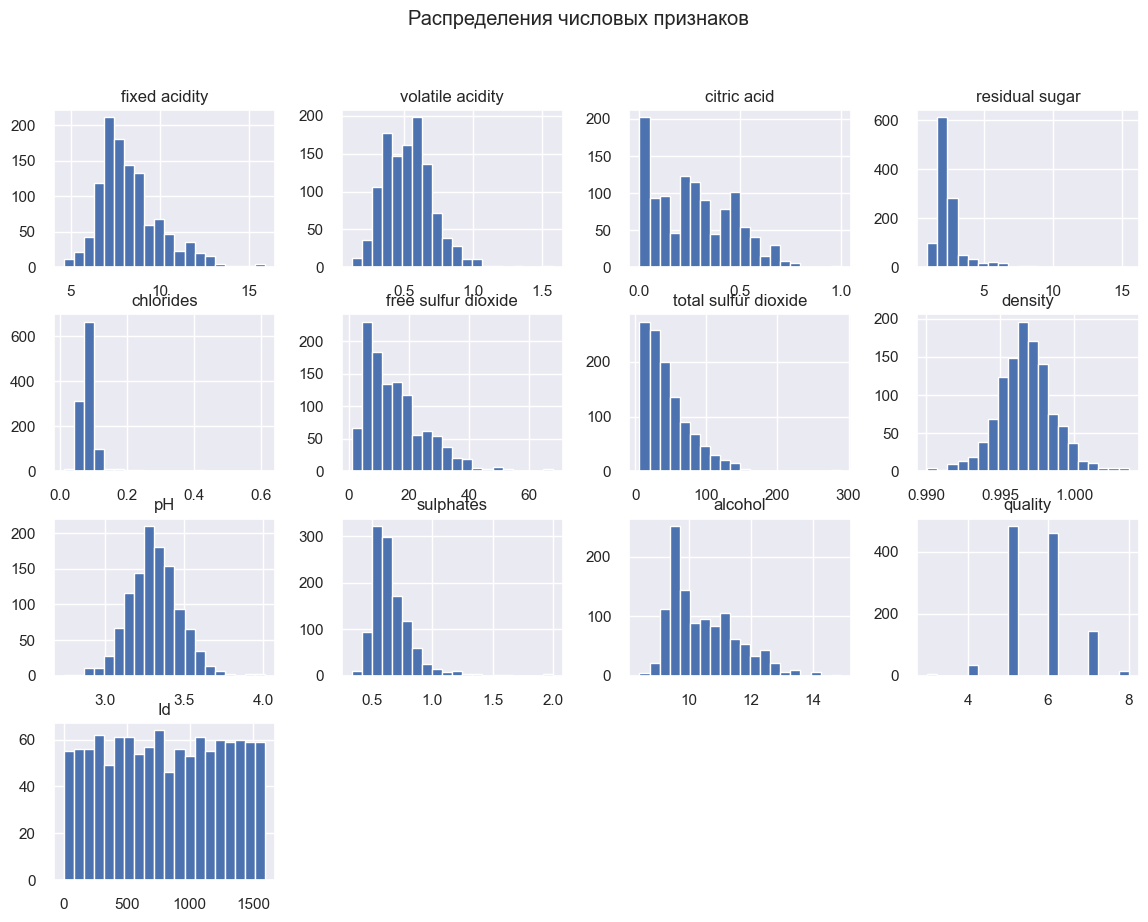

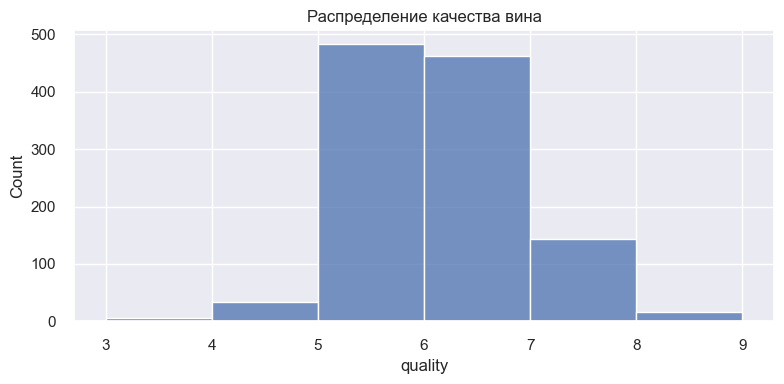

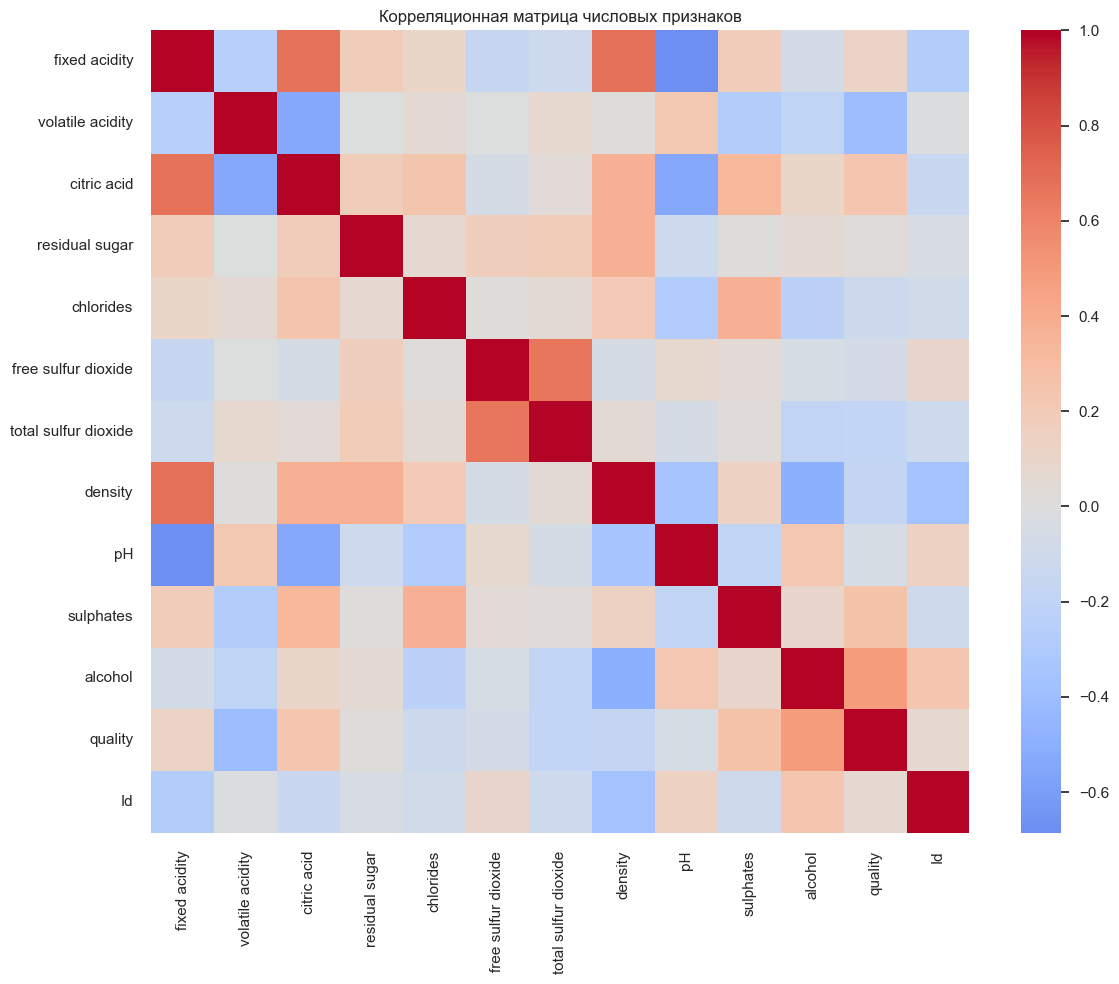

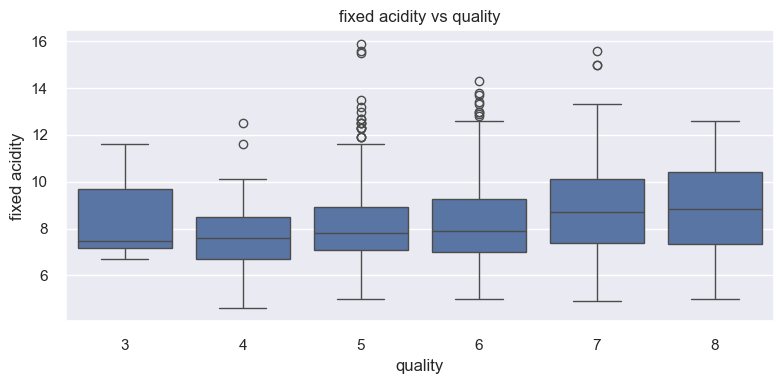

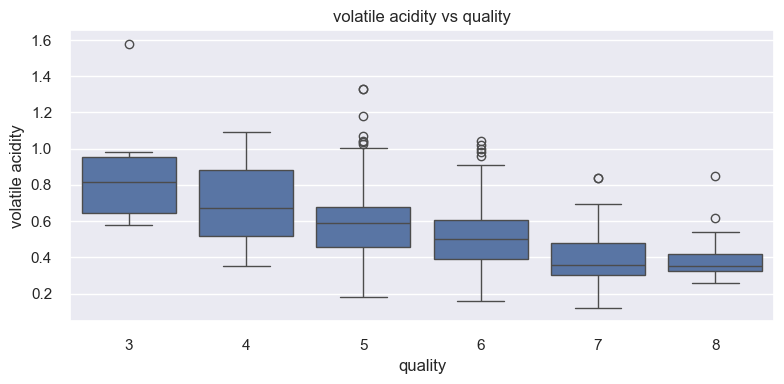

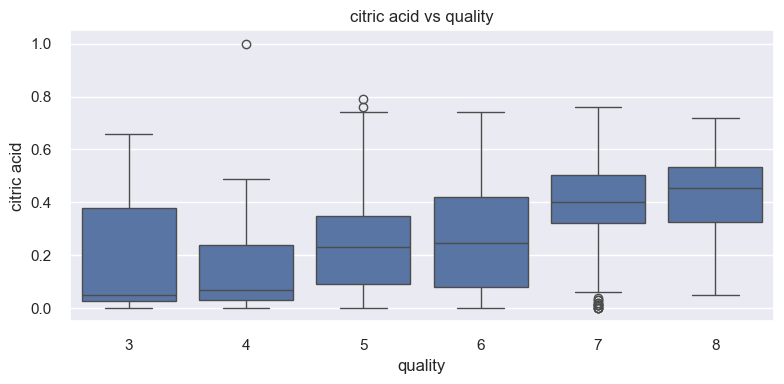

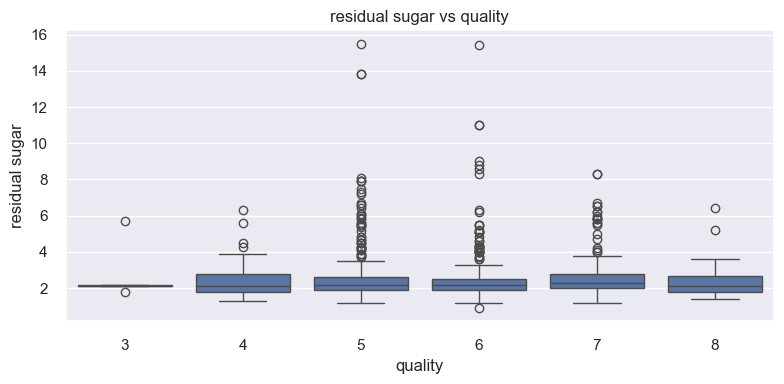

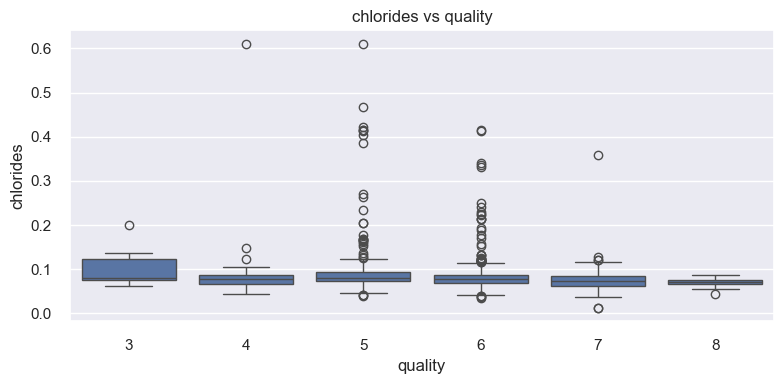

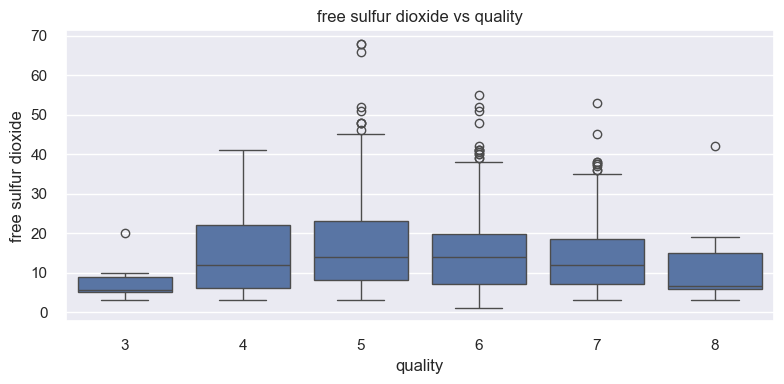

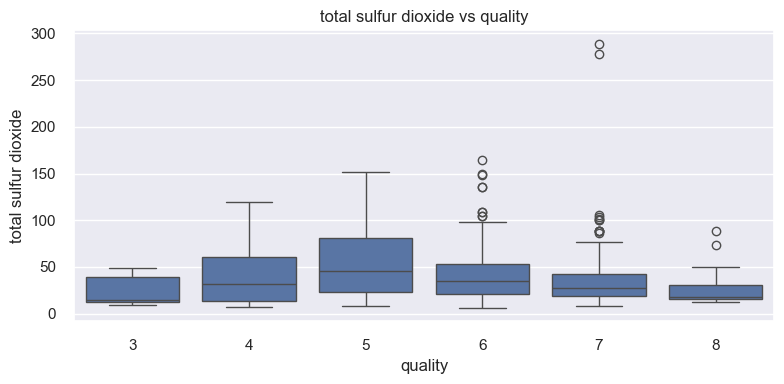

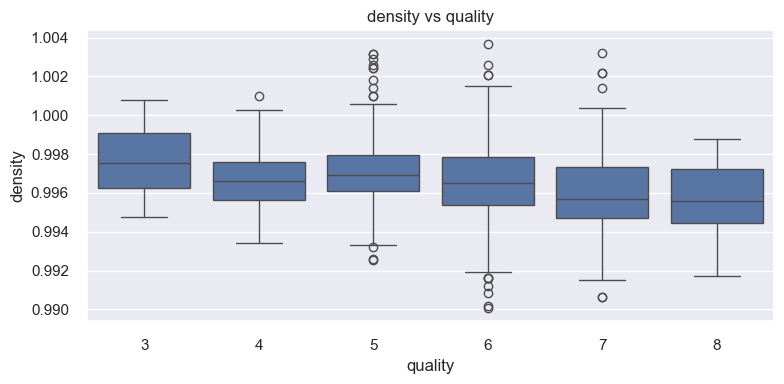

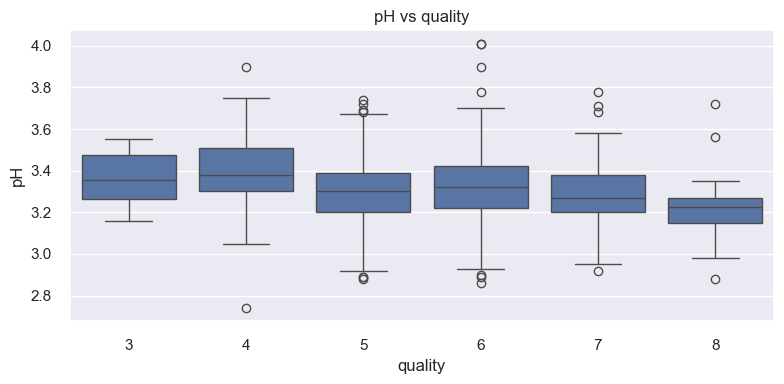

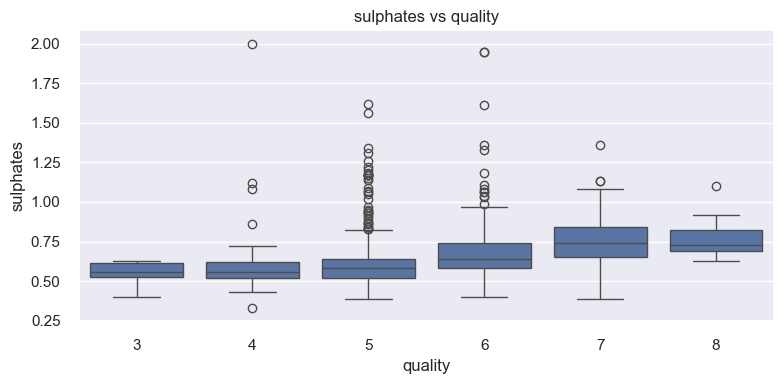

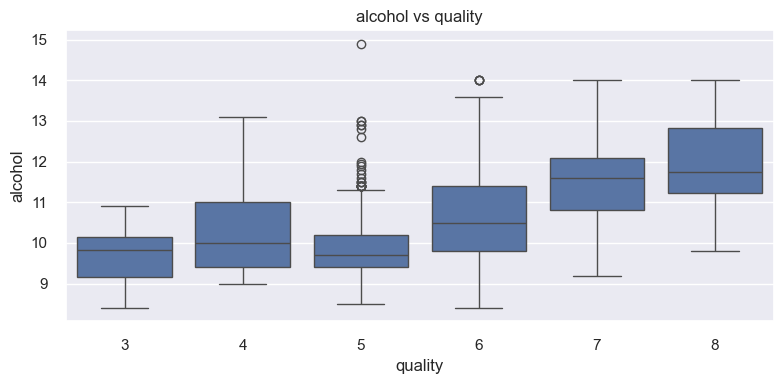

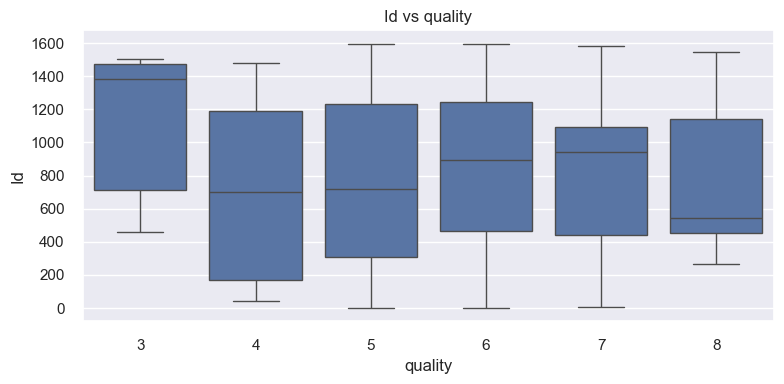

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "wine", "WineQT.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv(DATA_PATH)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe(include=[np.number]).T)

print("\nЧисло дубликатов:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
print("\nПропуски по столбцам:")
display(missing[missing > 0])

target_col = "quality"

if target_col in df.columns:
    print("\nРаспределение целевой переменной (качество):")
    display(df[target_col].value_counts().sort_index())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

sample_df = df.sample(n=min(len(df), 5000), random_state=42)

if numeric_cols:
    sample_df[numeric_cols].hist(bins=20, figsize=(14, 10))
    plt.suptitle("Распределения числовых признаков")
    plt.show()

if target_col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col], kde=False, bins=range(int(df[target_col].min()), int(df[target_col].max()) + 2))
    plt.title("Распределение качества вина")
    plt.tight_layout()
    plt.show()

if numeric_cols:
    plt.figure(figsize=(12, 10))
    corr = sample_df[numeric_cols].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Корреляционная матрица числовых признаков")
    plt.tight_layout()
    plt.show()

if target_col in df.columns:
    for col in numeric_cols:
        if col == target_col:
            continue
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=target_col, y=col, data=sample_df)
        plt.title(f"{col} vs {target_col}")
        plt.tight_layout()
        plt.show()
